### The goal of this notebook is to test various simulation methods, as well as to cluster final conformations to compare methods.

In [1]:
import numpy as np  # Numerical operations and array manipulations
import matplotlib.pyplot as plt  # Plotting and data visualization
import pandas as pd  # Data structures for handling data (e.g., DataFrame)
import visualization_functions as vis # our functions for visualization
import sim_methods as sim # our functions for simulation

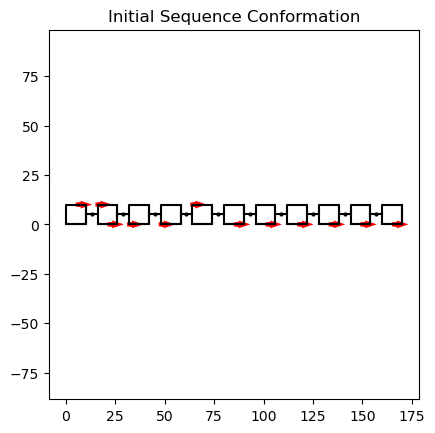

In [2]:
shapes = {'shape 1': ['s', 10, 0, 0, {'patch 1': ['top right', 4, 0]}], 'shape 2':['s', 10, 6, 0, {'patch 1': ['top left', 4, 0], 'patch 2': ['bottom right', 4, 0]}], 'shape 3': ['s', 10, 6, 0, {'patch 1': ['bottom left', 4, 0]}], 
          'shape 4': ['s', 10, 6, 0, {'patch 1': ['bottom left', 4, 0]}], 'shape 5': ['s', 10, 6, 0, {'patch 1': ['top left', 4, 0]}], 'shape 6': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 7': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 8': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 9': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 10': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 11': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}]}

hinge_vec, hinge_loc, shape_arr, linelist, patch_arr, patch_num = vis.generate(shapes)

vis.shapeplots(shape_arr, linelist, hinge_loc, blocking = False, title = 'Initial Sequence Conformation', show = True, bounds = '', mag_vecs = patch_arr)

# Define the magnetization/length of each patch. This is defined from experimental measured values as mentioned in the manuscript
m = np.array([1.01e-6]*sum(patch_num)) # Can change the values of the moments here if we do patches of different sizes

# Establish the magnetic vector containing all of the magnetizations/shape of each magnetic domain (ends of the patches), necessary for energy calculation
magvec = np.repeat(m, 2) # the endpoints are the domains we care about, so this is just a 2n-dim array of the same values as m, where n is the dim of m

mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat = vis.initialize_energy(magvec)

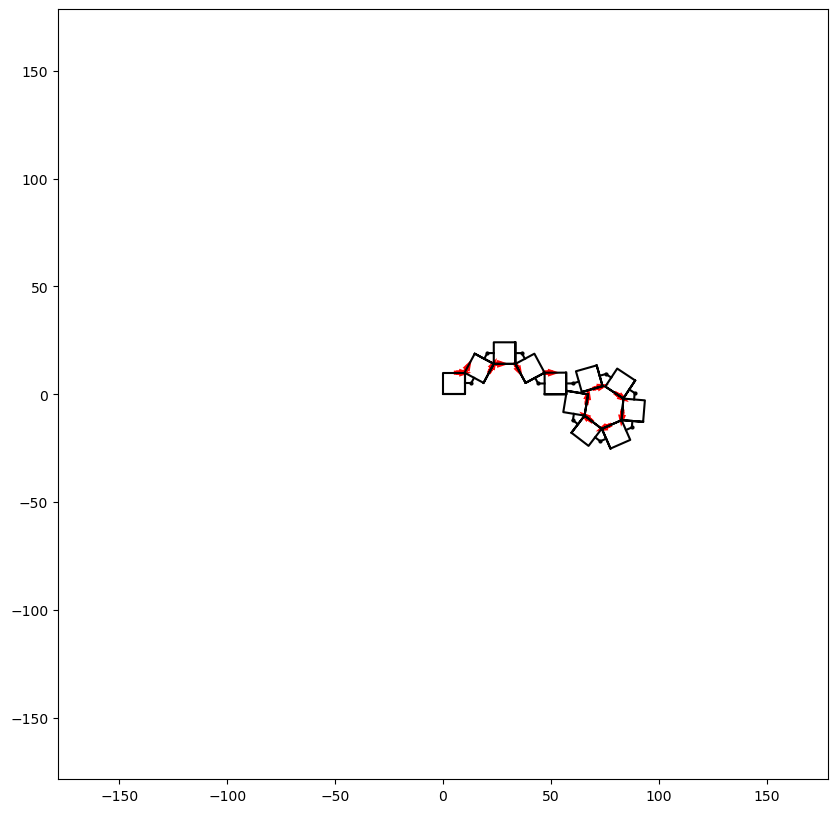

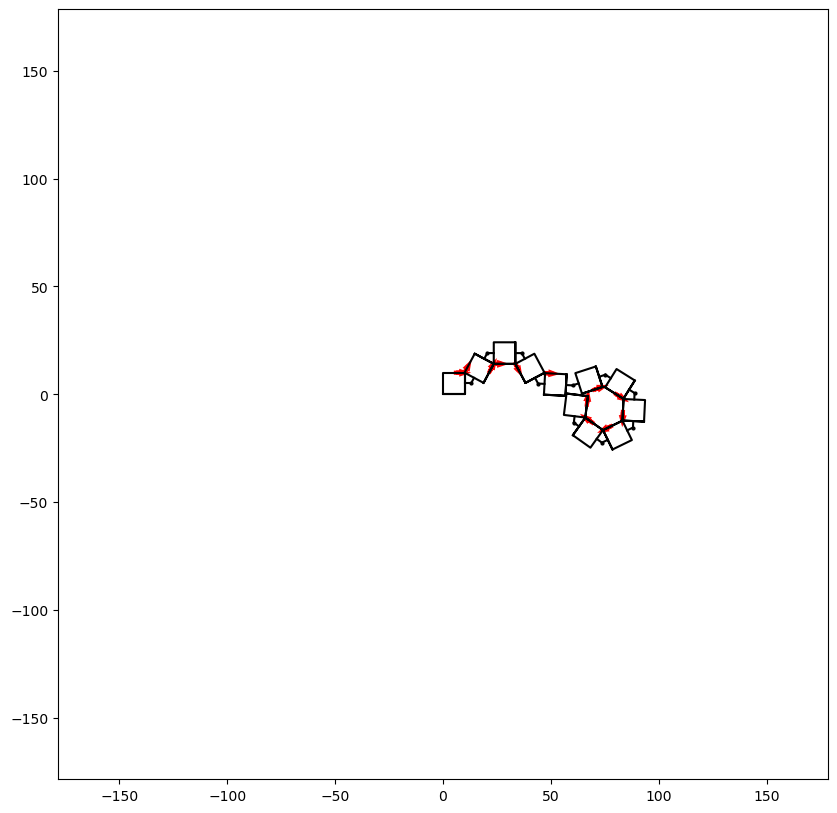

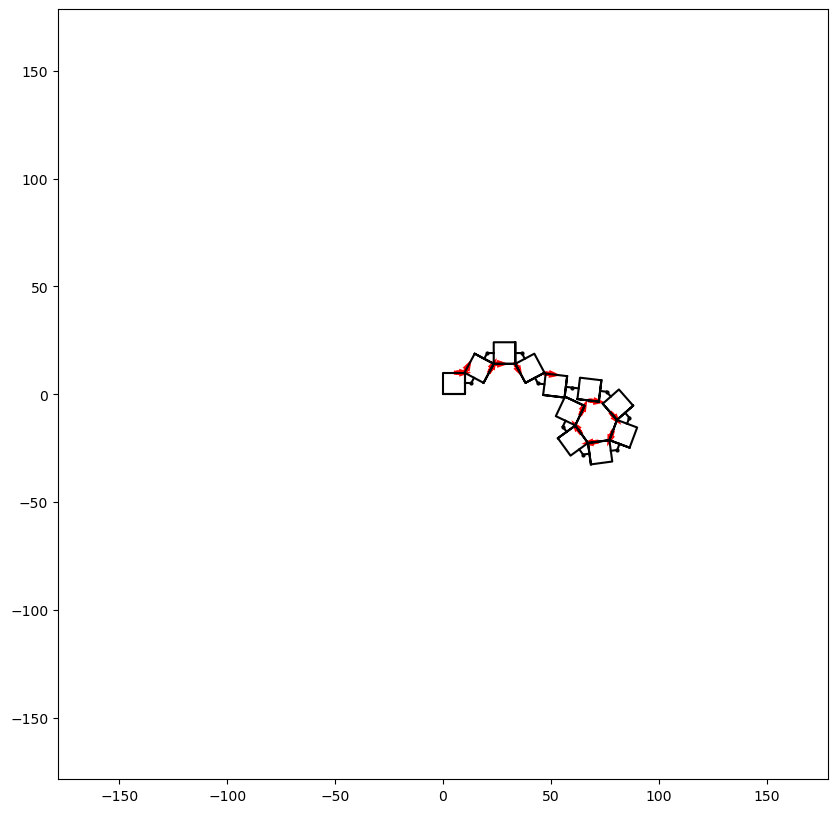

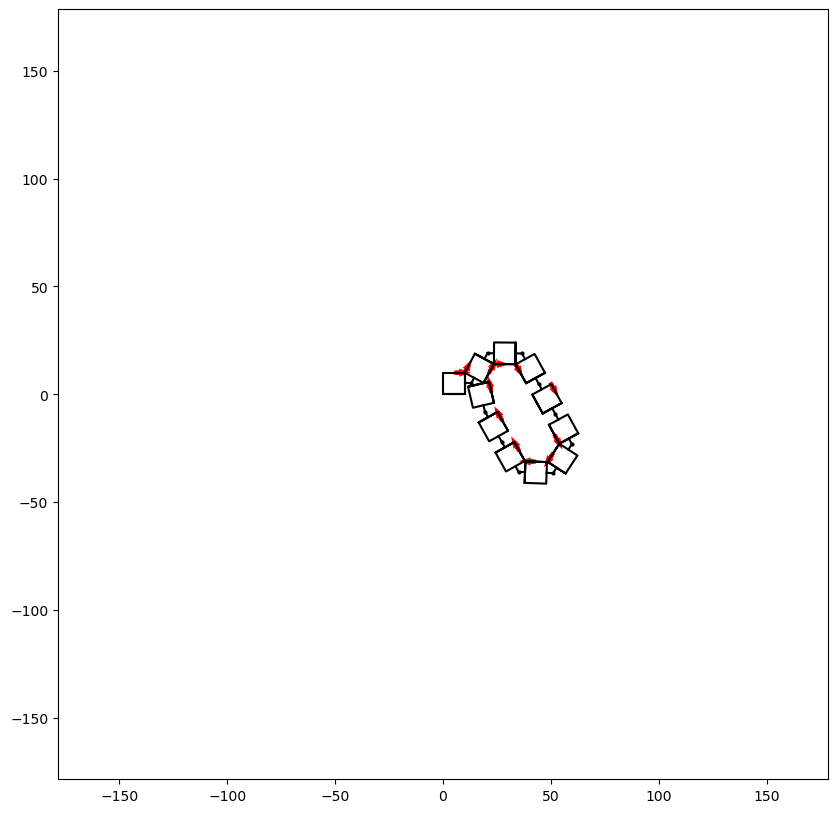

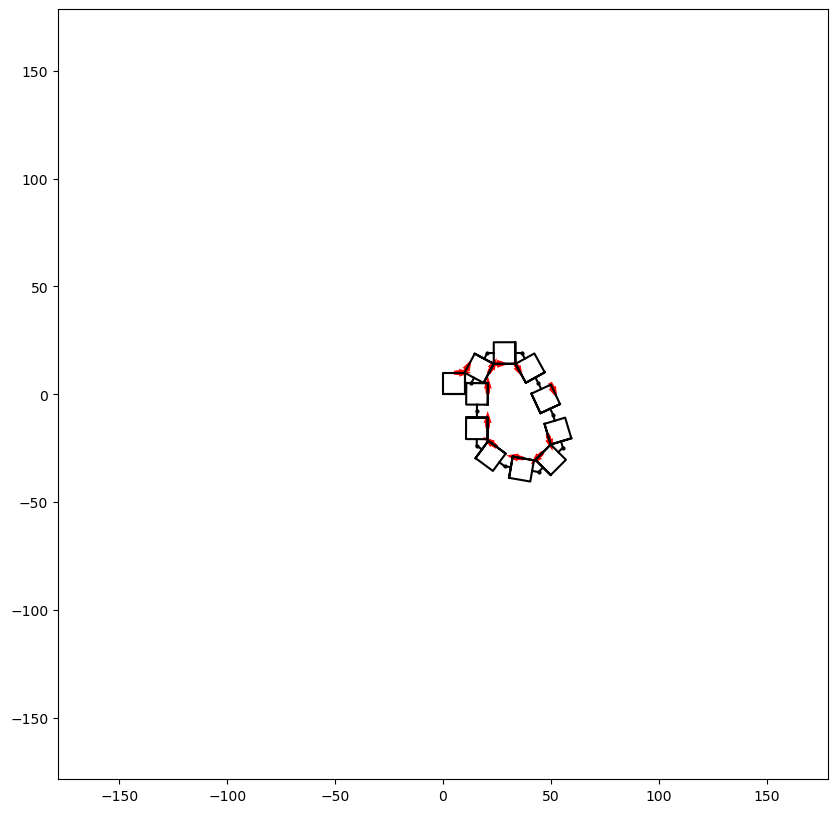

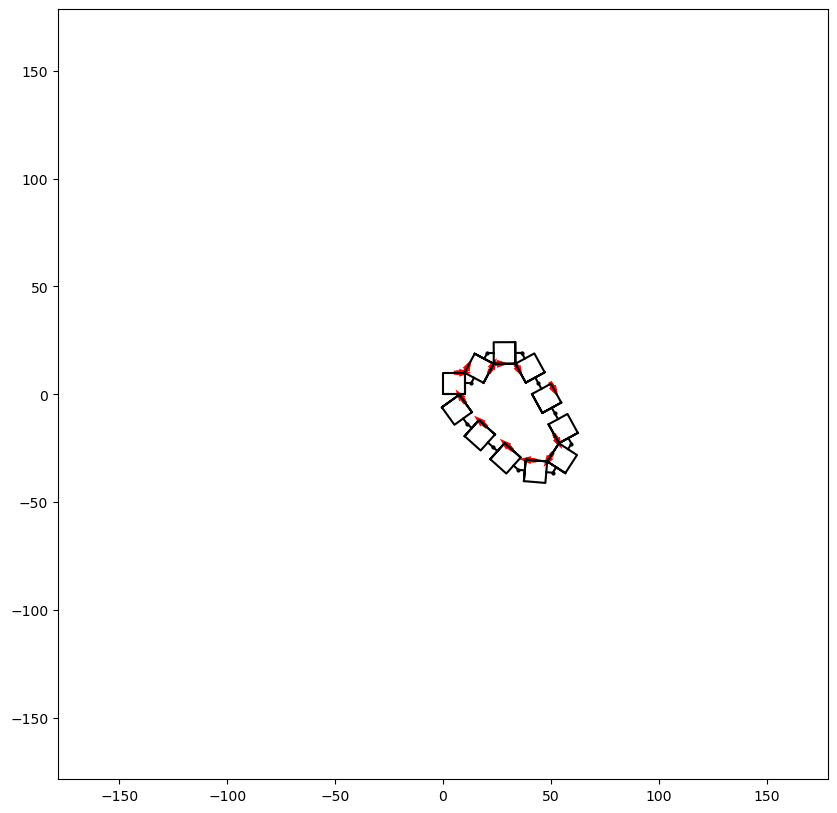

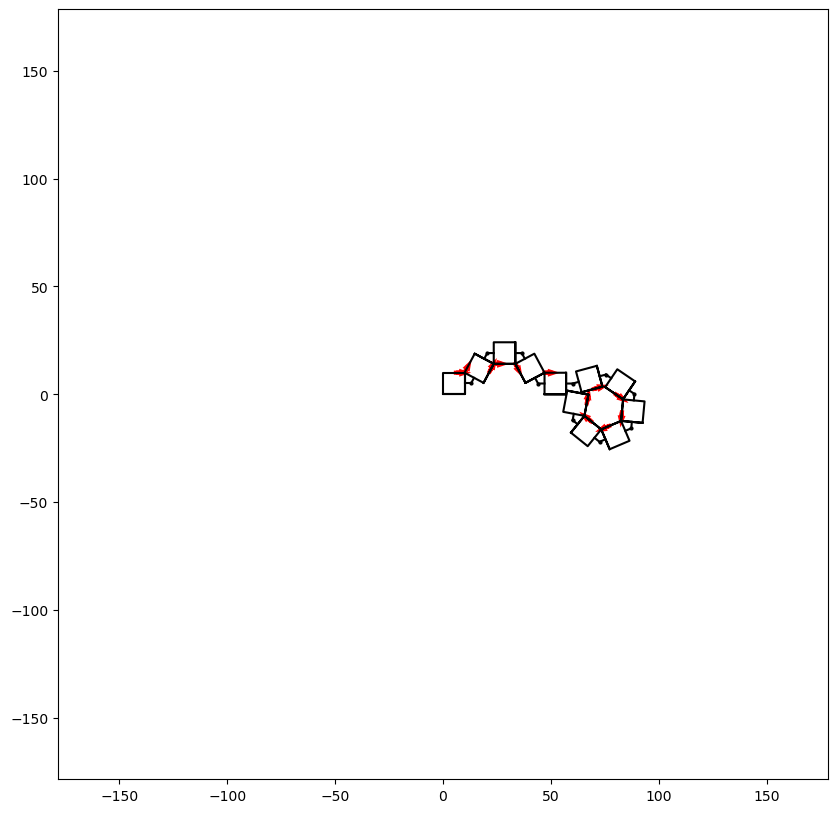

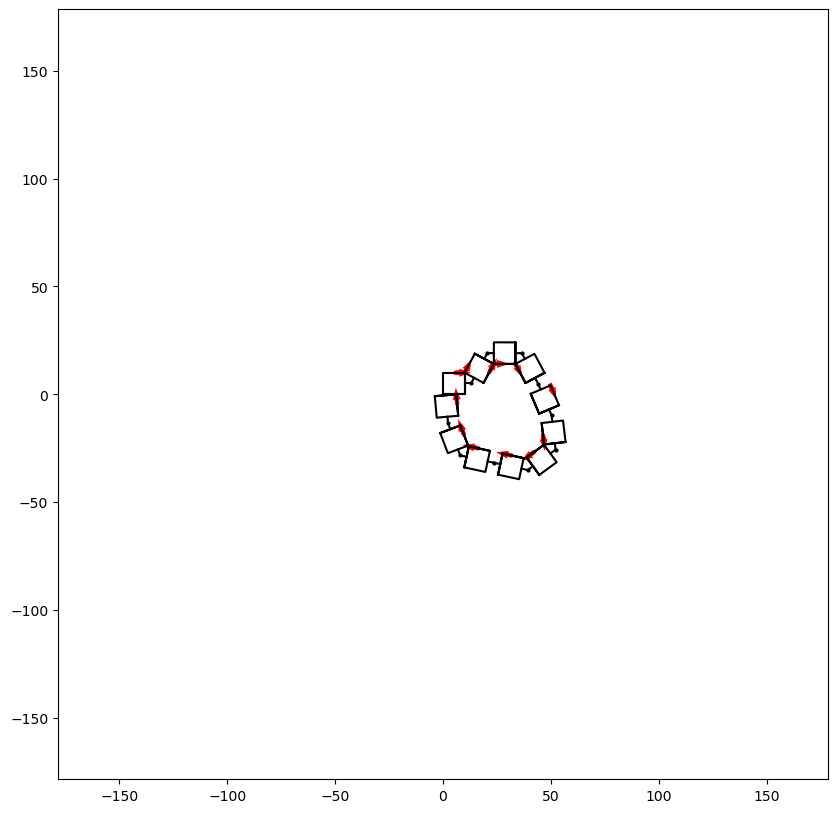

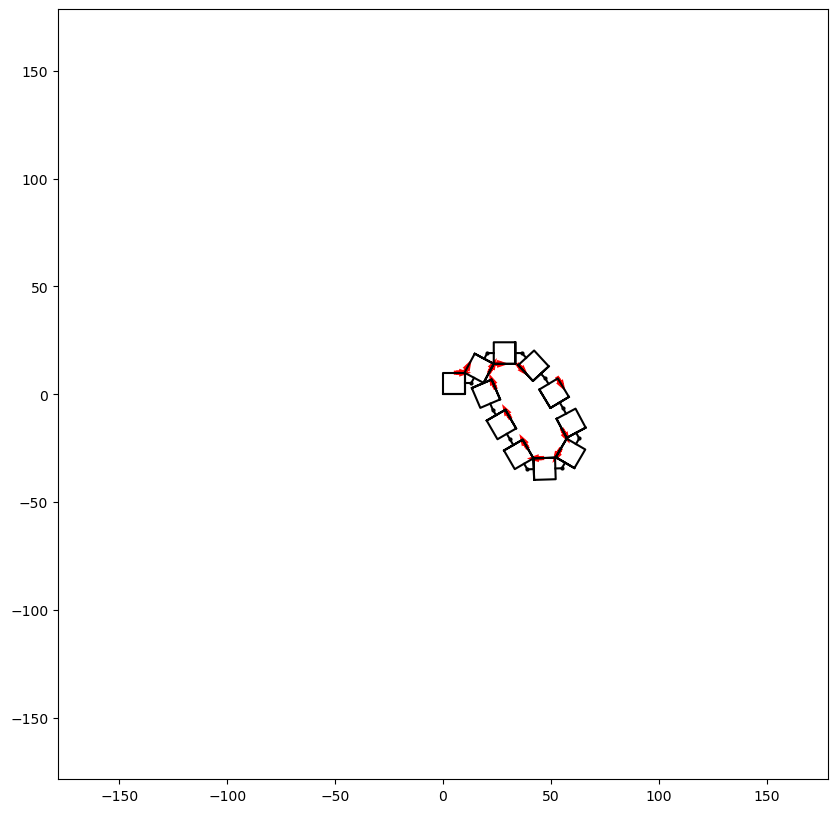

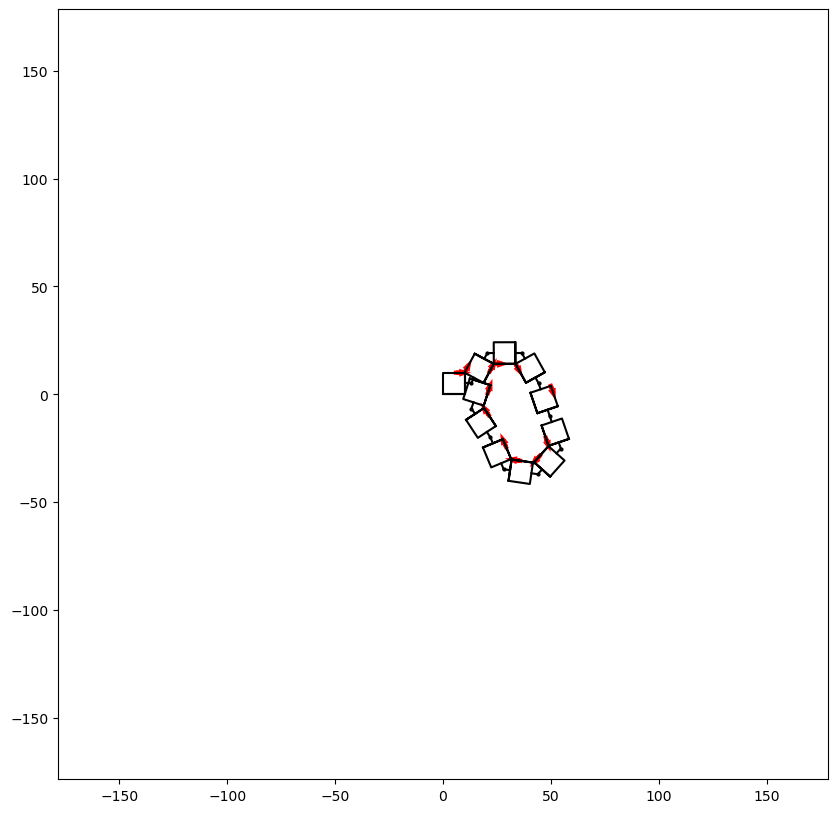

In [5]:
# sim many times
std = 10 # angle distribution std
max_iter = 1000 # maximum moves
nsim = 10 # number of simulations
final_hinges, final_es = sim.sim_many(nsim, 'greedy descent',patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=True)